# PadChest-GR grounded Training



## 1. Install and mount

In [ ]:
!pip install -q transformers accelerate bitsandbytes peft datasets


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, json, time, math, copy, random, hashlib, shutil, subprocess
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

OUT_ROOT = "/content/drive/MyDrive/MSC_VLM_GROUNDED"
RUN_NAME = "B_final"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("runs:", [d for d in os.listdir(OUT_ROOT) if d.startswith("run_")])

Mounted at /content/drive
device: cuda
runs: ['run_A_iu', 'run_B_gf0.5_COLLAPSED_lr1e-4_accum16', 'run_B_COLLAPSED_mlp_adapter', 'run_B_padchest_gf0.5', 'run_B_linearMLP', 'run_B_linearMLP_s1', 'run_B_lora5e6']


## 2. Restore data

In [ ]:
PNG_TAR, PNG_LOCAL = f"{OUT_ROOT}/pcgr_png.tar", "/content/pc_png"
if not os.path.exists(f"{PNG_LOCAL}/manifest.json"):
    if not os.path.isdir(PNG_LOCAL) or len(os.listdir(PNG_LOCAL)) < 100:
        print("restoring from tar...")
        subprocess.run(["tar", "-xf", PNG_TAR, "-C", "/content"])
    if not os.path.exists(f"{PNG_LOCAL}/manifest.json"):
        shutil.copy(f"{OUT_ROOT}/manifest.json", f"{PNG_LOCAL}/manifest.json")

pc_all = json.load(open(f"{PNG_LOCAL}/manifest.json"))
n_png = len([f for f in os.listdir(PNG_LOCAL) if f.endswith(".png")])
print(f"{len(pc_all)} studies | {n_png} PNGs")
assert len(pc_all) == 4555 and n_png == 4555

restoring from tar...
4555 studies | 4555 PNGs


## 3. Config

`

In [ ]:
import re

class CFG:
    SEED = 42

    # vision
    IMG_SIZE = 518
    PATCH = 14
    RAW_GRID = 37                  # 518 / 14
    POOL_GRID = 19
    VISION_DIM = 768

    # coordinate vocabulary
    COORD_BINS = 32                # -> 64 tokens (32 x + 32 y)

    # llm
    LLM_ID = "Qwen/Qwen2.5-3B-Instruct"
    LORA_R = 32
    LORA_ALPHA = 64
    LORA_DROPOUT = 0.05
    LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"]

    # training
    EPOCHS = 1
    BATCH = 1
    ACCUM = 8
    LR = 2e-6
    LR_ADAPTER = 5e-5
    WARMUP_FRAC = 0.03
    MAX_LEN = 512
    GROUNDED_FRACTION = 1.0
    # decoding
    MAX_NEW_TOKENS = 220
    DO_SAMPLE = True
    TOP_P = 0.9
    TEMPERATURE = 0.7


def seed_everything(s=CFG.SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)


# ==============================================================================
# PROMPTS
# ==============================================================================

SYSTEM = ("<|im_start|>system\nYou are an expert radiology assistant tasked "
          "with interpreting a chest X-ray study.<|im_end|>\n")

INSTR_FINDGEN = (
    "<|im_start|>user\nProvide a description of the findings in the radiology "
    "study. Each finding should be described as a self-contained plain-text "
    "sentence.<|im_end|>\n<|im_start|>assistant\n")

INSTR_GROUNDREP = (
    "<|im_start|>user\nProvide a description of the findings in the radiology "
    "study. Each finding should be described as a self-contained plain-text "
    "sentence. If the finding is groundable, locate it in the image with "
    "bounding boxes indicating all locations where it can be seen. Otherwise "
    "generate just the ungrounded finding.<|im_end|>\n<|im_start|>assistant\n")


# ==============================================================================
# COORDINATE VOCABULARY
# ==============================================================================

OBJ_OPEN, OBJ_CLOSE = "<obj>", "</obj>"
BOX_OPEN, BOX_CLOSE = "<box>", "</box>"


def coord_tokens(n=CFG.COORD_BINS):
    return ([f"<x{i}>" for i in range(n)] + [f"<y{i}>" for i in range(n)]
            + [OBJ_OPEN, OBJ_CLOSE, BOX_OPEN, BOX_CLOSE])


def add_coord_tokens(tokenizer, model, n=CFG.COORD_BINS):

    new = coord_tokens(n)
    added = tokenizer.add_tokens(new, special_tokens=True)
    if added == 0:
        return tokenizer, model
    model.resize_token_embeddings(len(tokenizer))
    with torch.no_grad():
        emb = model.get_input_embeddings().weight
        old = emb[:-added].float()
        mu, sd = old.mean(0, keepdim=True), old.std(0, keepdim=True)
        emb[-added:] = (mu + torch.randn(added, emb.shape[1],
                                         device=emb.device) * sd).to(emb.dtype)
        out = model.get_output_embeddings()
        if out is not None and out.weight.data_ptr() != emb.data_ptr():
            o = out.weight[:-added].float()
            om, os_ = o.mean(0, keepdim=True), o.std(0, keepdim=True)
            out.weight[-added:] = (om + torch.randn(added, o.shape[1],
                                                    device=o.device) * os_
                                   ).to(out.weight.dtype)
        chk = emb[-added:]
        spread = chk.float().std(0).mean().item()
    print(f"added {added} tokens | vocab {len(tokenizer)} | "
          f"new-row spread {spread:.5f} (must be > 0)")
    assert spread > 1e-4, "coordinate tokens are identical — init failed"
    return tokenizer, model


def box_to_tokens(box_norm, n=CFG.COORD_BINS):
    """(x0,y0,x1,y1) normalised to [0,1] -> '<x><y><x><y>' token string."""
    x0, y0, x1, y1 = box_norm
    q = lambda v: int(np.clip(round(v * (n - 1)), 0, n - 1))
    return f"<x{q(x0)}><y{q(y0)}><x{q(x1)}><y{q(y1)}>"


BOX_RE = re.compile(r"<x(\d+)><y(\d+)><x(\d+)><y(\d+)>")


def parse_generation(text, n=CFG.COORD_BINS):

    out = []
    for chunk in re.findall(r"<obj>(.*?)</obj>", text, flags=re.S):
        boxes = [(int(a)/(n-1), int(b)/(n-1), int(c)/(n-1), int(d)/(n-1))
                 for a, b, c, d in BOX_RE.findall(chunk)]
        sent = re.sub(r"<box>.*?</box>", "", chunk, flags=re.S)
        sent = BOX_RE.sub("", sent).strip()
        if sent:
            out.append((sent, boxes))
    if not out and text.strip():                  # ungrounded fallback
        out = [(text.strip(), [])]
    return out


# ==============================================================================
# GEOMETRY — image and boxes through the identical transform
# ==============================================================================

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], np.float32)


def preprocess(pil_img, boxes_xyxy=None, size=CFG.IMG_SIZE):

    W, H = pil_img.size
    scale = size / min(W, H)
    nw, nh = int(round(W * scale)), int(round(H * scale))
    img = pil_img.convert("RGB").resize((nw, nh), Image.BILINEAR)
    ox, oy = max(0, (nw - size) // 2), max(0, (nh - size) // 2)
    img = img.crop((ox, oy, ox + size, oy + size))

    arr = np.asarray(img, np.float32) / 255.0
    arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
    px = torch.from_numpy(arr).permute(2, 0, 1)

    if boxes_xyxy is None:
        return px, None, img

    out = []
    for b in boxes_xyxy:
        nb = (b[0]*scale - ox, b[1]*scale - oy, b[2]*scale - ox, b[3]*scale - oy)
        cl = (max(0., nb[0]), max(0., nb[1]),
              min(float(size), nb[2]), min(float(size), nb[3]))
        oa = max(1e-6, (nb[2]-nb[0]) * (nb[3]-nb[1]))
        sa = max(0., cl[2]-cl[0]) * max(0., cl[3]-cl[1])
        out.append(tuple(v / size for v in cl) if sa/oa >= 0.30 else None)
    return px, out, img




### 3.1 Prompts, coordinate vocabulary, geometry, formatting

`add_coord_tokens` uses per-token random initialisation and **asserts** the new
rows are not identical — that assert is bug 4's regression test.

In [ ]:
# ==============================================================================
# TARGET FORMATTING
# ==============================================================================

def format_findgen(sentences):
    """Run A, and the ungrounded half of Run B."""
    return " ".join(s.strip() for s in sentences if s.strip())


def format_groundrep(sentences, boxes_per_sentence):

    parts = []
    for sent, boxes in zip(sentences, boxes_per_sentence):
        s = sent.strip()
        if not s:
            continue
        valid = [b for b in boxes if b is not None]
        if valid:
            btxt = "".join(BOX_OPEN + box_to_tokens(b) + BOX_CLOSE for b in valid)
            parts.append(f"{OBJ_OPEN}{s}{btxt}{OBJ_CLOSE}")
        else:
            parts.append(f"{OBJ_OPEN}{s}{OBJ_CLOSE}")
    return "".join(parts)


# ==============================================================================
# ABSTENTION — three categories
# ==============================================================================

NEGATION_CUES = ["no ", "not ", "without", "free of", "clear of", "negative for",
                 "absence of", "absent", "unremarkable", "normal limits",
                 "within normal", "no evidence"]
NORMALITY_CUES = ["are clear", "is clear", "is normal", "are normal",
                  "unremarkable", "within normal limits", "no abnormalit",
                  "intact", "well-inflated", "well expanded"]
NON_LOCALISABLE_CUES = ["diffuse", "generalised", "generalized", "widespread",
                        "throughout", "global", "hyperinflat", "hypoinflat",
                        "low lung volumes", "emphysema", "copd", "osteopenia",
                        "deminerali", "scoliosis"]


def is_groundable(sentence):
    s = " " + sentence.lower().strip() + " "
    if any(c in s for c in NEGATION_CUES):        return False
    if any(c in s for c in NORMALITY_CUES):       return False
    if any(c in s for c in NON_LOCALISABLE_CUES): return False
    return True


# ==============================================================================
# SPLITS
# ==============================================================================

def study_key(text):

    return hashlib.md5(re.sub(r"\s+", " ", (text or "").strip().lower())
                       .encode()).hexdigest()


def group_split(keys, frac=(0.8, 0.1, 0.1), seed=CFG.SEED):
    uniq = sorted(set(keys)); random.Random(seed).shuffle(uniq)
    n, a, b = len(uniq), int(len(uniq)*frac[0]), int(len(uniq)*(frac[0]+frac[1]))
    assign = {k: ("train" if i < a else "val" if i < b else "test")
              for i, k in enumerate(uniq)}
    out = {"train": [], "val": [], "test": []}
    for i, k in enumerate(keys):
        out[assign[k]].append(i)
    return out


def symmetry_score(pil_img, size=128):
    """Frontal CXRs are near left-right symmetric; laterals are not."""
    a = np.asarray(pil_img.convert("L").resize((size, size)), np.float32)
    b = a[:, ::-1]
    a = (a - a.mean()) / (a.std() + 1e-8)
    b = (b - b.mean()) / (b.std() + 1e-8)
    return float((a * b).mean())


FRONTAL_THRESHOLD = 0.68

## 4. Adapter

Linear + LayerNorm + learnable scale. Deliberately shallow: Rad-DINO was
pretrained on 1.4M chest X-rays, so the adapter should transport its
representation, not relearn it from 2,479 studies.

`scale` is a live diagnostic — rising means the model wants the image louder,
decaying toward zero means it is muting it.

In [ ]:
class SpatialMLPAdapter(nn.Module):


    def __init__(self, vision_dim=CFG.VISION_DIM, llm_dim=2048,
                 raw_grid=CFG.RAW_GRID, pool_grid=CFG.POOL_GRID,
                 target_norm=1.0):
        super().__init__()
        self.raw_grid, self.pool_grid = raw_grid, pool_grid
        self.proj = nn.Linear(vision_dim, llm_dim)
        self.norm = nn.LayerNorm(llm_dim)
        self.scale = nn.Parameter(torch.tensor(target_norm / (llm_dim ** 0.5)))

    def forward(self, rad_out):
        x = rad_out[:, 1:, :]
        B, N, C = x.shape
        assert N == self.raw_grid ** 2, (
            f"expected {self.raw_grid**2} patches, got {N}")
        x = x.transpose(1, 2).reshape(B, C, self.raw_grid, self.raw_grid)
        x = F.adaptive_avg_pool2d(x, (self.pool_grid, self.pool_grid))
        x = x.flatten(2).transpose(1, 2)
        return self.norm(self.proj(x)) * self.scale


seed_everything()
print("adapter class ready")

adapter class ready


## 5. Split — abnormal studies only

In [ ]:
def patient_level_split(manifest, frac=(0.80, 0.10, 0.10), seed=42):
    groups = {}
    for m in manifest:
        groups.setdefault(str(m["patient_id"]), []).append(m)
    abn = [k for k, v in groups.items() if any(x["abnormal"] for x in v)]
    nrm = [k for k, v in groups.items() if not any(x["abnormal"] for x in v)]
    rng = random.Random(seed); rng.shuffle(abn); rng.shuffle(nrm)
    out = {"train": [], "val": [], "test": []}
    ids = {"train": set(), "val": set(), "test": set()}
    for pool in (abn, nrm):
        a, b = int(len(pool)*frac[0]), int(len(pool)*(frac[0]+frac[1]))
        for nm, ks in [("train", pool[:a]), ("val", pool[a:b]), ("test", pool[b:])]:
            for k in ks:
                out[nm].extend(groups[k]); ids[nm].add(k)
    assert ids["train"].isdisjoint(ids["val"])
    assert ids["train"].isdisjoint(ids["test"])
    assert ids["val"].isdisjoint(ids["test"])
    return out["train"], out["val"], out["test"]


pc_train, pc_val, pc_test = patient_level_split(pc_all)
tr_abn = [m for m in pc_train if m["abnormal"]]
va_abn = [m for m in pc_val   if m["abnormal"]]
te_abn = [m for m in pc_test  if m["abnormal"]]

ns = sum(len(m["sentences"]) for m in tr_abn)
ng = sum(sum(1 for b in m["boxes"] if b) for m in tr_abn)
print(f"ABNORMAL-ONLY  train {len(tr_abn)} | val {len(va_abn)} | test {len(te_abn)}")
print(f"train sentences {ns} | with box {ng} ({100*ng/ns:.1f}%)")
print("\n(full split was 3643/456/456 at 68.0% abnormal)")

ABNORMAL-ONLY  train 2479 | val 310 | test 310
train sentences 6955 | with box 5034 (72.4%)

(full split was 3643/456/456 at 68.0% abnormal)


## 6. Model

In [ ]:
def build_model():
    from transformers import (AutoModel, AutoTokenizer, AutoModelForCausalLM,
                              BitsAndBytesConfig)
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

    print("Rad-DINO (frozen)...")
    vision = AutoModel.from_pretrained("microsoft/rad-dino").to(device).eval()
    for p in vision.parameters():
        p.requires_grad = False

    print("Qwen2.5-3B (4-bit) + LoRA...")
    tok = AutoTokenizer.from_pretrained(CFG.LLM_ID)
    tok.pad_token = tok.eos_token
    tok.padding_side = "right"
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_use_double_quant=True,
                             bnb_4bit_quant_type="nf4",
                             bnb_4bit_compute_dtype=torch.float16)
    base = AutoModelForCausalLM.from_pretrained(
        CFG.LLM_ID, quantization_config=bnb, device_map={"": 0})


    tok, base = add_coord_tokens(tok, base)
    base = prepare_model_for_kbit_training(base)


    lora = LoraConfig(r=CFG.LORA_R, lora_alpha=CFG.LORA_ALPHA,
                      lora_dropout=CFG.LORA_DROPOUT, bias="none",
                      task_type="CAUSAL_LM", target_modules=CFG.LORA_TARGETS)
    llm = get_peft_model(base, lora)
    llm.config.use_cache = False
    llm.gradient_checkpointing_enable()
    llm.enable_input_require_grads()


    n_new = len(coord_tokens())
    emb = llm.get_input_embeddings()
    emb.weight.requires_grad_(True)
    mask = torch.zeros(emb.weight.shape[0], 1,
                       device=emb.weight.device, dtype=emb.weight.dtype)
    mask[-n_new:] = 1.0
    emb.weight.register_hook(lambda g: g * mask)
    llm._n_new_tokens = n_new

    adapter = SpatialMLPAdapter(llm_dim=llm.config.hidden_size).to(device)

    n_ad = sum(p.numel() for p in adapter.parameters())
    n_lora = sum(p.numel() for n, p in llm.named_parameters()
                 if p.requires_grad and "embed_tokens" not in n)
    n_emb_eff = n_new * emb.weight.shape[1]        # effective, after masking
    n_frozen = sum(p.numel() for p in llm.parameters()) \
        + sum(p.numel() for p in vision.parameters())
    tot = n_ad + n_lora + n_emb_eff
    print(f"\nTRAINABLE PARAMETERS")
    print(f"  MLP adapter          {n_ad:>12,}")
    print(f"  LoRA (r={CFG.LORA_R})           {n_lora:>12,}")
    print(f"  coord embeddings     {n_emb_eff:>12,}  "
          f"({n_new} tokens x {emb.weight.shape[1]})")
    print(f"  ------------------------------------")
    print(f"  total trainable      {tot:>12,}  ({100*tot/max(1,n_frozen):.2f}% "
          f"of the frozen backbone)")
    return vision, tok, llm, adapter

In [ ]:
@torch.no_grad()
def encode_image(vision, px):
    return vision(px.to(device)).last_hidden_state

vision, tok, llm, adapter = build_model()
assert hasattr(adapter, "scale") and not hasattr(adapter, "mlp"), "WRONG ADAPTER"

new = llm.get_input_embeddings().weight[-68:]
print(f"\ncoord-token spread: {new.float().std(0).mean().item():.5f}  (must be > 0)")
print(f"pairwise cosine   : {F.cosine_similarity(new[0], new[1], dim=0).item():.4f}"
      f"  (1.0000 would be the mean-init bug)")
assert new.float().std(0).mean().item() > 1e-4

Rad-DINO (frozen)...


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

added 68 tokens | vocab 151733 | new-row spread 0.02339 (must be > 0)

TRAINABLE PARAMETERS
  MLP adapter             1,579,009
  LoRA (r=32)             59,867,136
  coord embeddings          139,264  (68 tokens x 2048)
  ------------------------------------
  total trainable        61,585,409  (3.34% of the frozen backbone)

coord-token spread: 0.02339  (must be > 0)
pairwise cosine   : 0.0929  (1.0000 would be the mean-init bug)


## 7. Dataset

In [ ]:
def assign_objective(study_path, grounded_fraction, seed=CFG.SEED):

    h = hashlib.md5(f"{seed}:{study_path}".encode()).hexdigest()
    return "grounded" if (int(h[:8], 16) % 10000) / 10000.0 < grounded_fraction \
        else "findgen"

In [ ]:
class PadChestGRDataset(Dataset):
    """gf=1.0 here — every abnormal study trains the grounded objective."""
    def __init__(self, studies, gf, seed=CFG.SEED, quiet=False):
        self.studies = studies
        self.obj = [assign_objective(s["path"], gf, seed) for s in studies]
        if not quiet:
            n_g = sum(1 for o in self.obj if o == "grounded")
            print(f"  {n_g} grounded / {len(self.obj)-n_g} ungrounded "
                  f"({100*n_g/max(1,len(self.obj)):.1f}%)")

    def __len__(self): return len(self.studies)

    def __getitem__(self, i):
        s = self.studies[i]
        img = Image.open(s["path"])
        flat = [b for bl in s["boxes"] for b in bl]
        px, tx, _ = preprocess(img, flat)
        reg, k = [], 0
        for bl in s["boxes"]:
            g = []
            for _ in bl:
                if tx[k] is not None: g.append(tx[k])
                k += 1
            reg.append(g)
        if self.obj[i] == "grounded":
            return {"px": px, "target": format_groundrep(s["sentences"], reg),
                    "instr": INSTR_GROUNDREP, "objective": "grounded"}
        return {"px": px, "target": format_findgen(s["sentences"]),
                "instr": INSTR_FINDGEN, "objective": "findgen"}

In [ ]:
def make_collate(tok):
    def collate(batch):
        px = torch.stack([b["px"] for b in batch])
        prompts = [SYSTEM + b["instr"] for b in batch]
        fulls = [p + b["target"] + tok.eos_token for p, b in zip(prompts, batch)]
        enc = tok(fulls, return_tensors="pt", padding=True, truncation=True,
                  max_length=CFG.MAX_LEN)
        labels = enc["input_ids"].clone()
        labels[enc["attention_mask"] == 0] = -100

        for i, p in enumerate(prompts):
            labels[i, :len(tok(p, add_special_tokens=False)["input_ids"])] = -100
        return {"px": px, "input_ids": enc["input_ids"],
                "attention_mask": enc["attention_mask"], "labels": labels,
                "objective": [b["objective"] for b in batch]}
    return collate


def forward_loss(vision, llm, adapter, b):
    rad = encode_image(vision, b["px"])
    vis = adapter(rad.float())
    emb = llm.get_input_embeddings()(b["input_ids"].to(device))
    vis = vis.to(emb.dtype)                       # adapter fp32 vs Qwen bf16
    inp = torch.cat([vis, emb], dim=1)
    am = torch.cat([torch.ones(vis.shape[:2], dtype=torch.long, device=device),
                    b["attention_mask"].to(device)], dim=1)
    lab = torch.cat([torch.full(vis.shape[:2], -100, dtype=torch.long,
                                device=device), b["labels"].to(device)], dim=1)
    return llm(inputs_embeds=inp, attention_mask=am, labels=lab).loss

## 8. Diagnostics

`peek_forced` prefills `<obj>` so we measure content rather than whether greedy
enters the structured format.

In [ ]:
def signal_ratio(adapter_, studies):

    zs = []
    for s in studies:
        px, _, _ = preprocess(Image.open(s["path"]))
        with torch.no_grad():
            zs.append(adapter_(encode_image(vision, px[None]).float())[0]
                      .mean(0).float())
    Z = torch.stack(zs); shared = Z.mean(0)
    return (Z - shared).norm(dim=1).mean().item() / shared.norm().item()


def norm_ratio(adapter_, study):
    px, _, _ = preprocess(Image.open(study["path"]))
    with torch.no_grad():
        v = adapter_(encode_image(vision, px[None]).float())
    t = llm.get_input_embeddings()(
        tok(SYSTEM + INSTR_GROUNDREP, return_tensors="pt")["input_ids"].to(device))
    return (v[0].norm(dim=-1).mean() / t[0].float().norm(dim=-1).mean()).item()


@torch.no_grad()
def peek_forced(study, sampled=True, prefill="<obj>"):
    """Prefill the structured format, then generate."""
    px, _, _ = preprocess(Image.open(study["path"]))
    vis = adapter(encode_image(vision, px[None]).float())
    ids = tok(SYSTEM + INSTR_GROUNDREP + prefill,
              return_tensors="pt")["input_ids"].to(device)
    emb = llm.get_input_embeddings()(ids)
    inp = torch.cat([vis.to(emb.dtype), emb], dim=1)
    kw = dict(inputs_embeds=inp,
              attention_mask=torch.ones(inp.shape[:2], dtype=torch.long, device=device),
              max_new_tokens=CFG.MAX_NEW_TOKENS, pad_token_id=tok.eos_token_id)
    kw.update(dict(do_sample=True, top_p=CFG.TOP_P, temperature=CFG.TEMPERATURE,
                   repetition_penalty=1.15) if sampled else dict(do_sample=False))
    return prefill + tok.decode(llm.generate(**kw)[0], skip_special_tokens=False)


def status(tag, pool):
    llm.eval(); adapter.eval()
    outs = [peek_forced(s) for s in pool]
    nd, nb = len(set(outs)), sum(1 for o in outs if "<box>" in o)
    print(f"[{tag}] distinct {nd}/{len(pool)} | <box> {nb}/{len(pool)} | "
          f"signal {signal_ratio(adapter, pool):.3f} | "
          f"norm {norm_ratio(adapter, pool[0]):.2f} | "
          f"scale {adapter.scale.item():.5f}")
    for o in outs[:2]:
        print(f"    {o[:100]}")
    return nd, nb


check_pool = va_abn[:4]
b = make_collate(tok)([PadChestGRDataset(tr_abn[:1], 1.0, quiet=True)[0]])
llm.eval()
with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.float16):
    l0 = forward_loss(vision, llm, adapter, b).item()
print(f"untrained loss: {l0:.4f}   (want 6-9; 15.7 meant the mean-init bug)")
assert l0 < 12, "coordinate tokens still initialised below uniform"
status("untrained", check_pool)

untrained loss: 13.3101   (want 6-9; 15.7 meant the mean-init bug)


AssertionError: coordinate tokens still initialised below uniform

In [ ]:
ids, labels = b["input_ids"][0], b["labels"][0]
sup = (labels != -100).nonzero().flatten()
vis = adapter(encode_image(vision, b["px"]))
emb = llm.get_input_embeddings()(b["input_ids"].to(device))
inp = torch.cat([vis.to(emb.dtype), emb], dim=1)
with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.float16):
    logits = llm(inputs_embeds=inp,
                 attention_mask=torch.ones(inp.shape[:2], dtype=torch.long,
                                           device=device)).logits
lp = torch.log_softmax(logits.float(), -1)
nv = vis.shape[1]

import math
coord_ids = set(tok.convert_tokens_to_ids(coord_tokens()))
nc, nt = [], []
for t in sup.tolist():
    tid = ids[t].item()
    nll = -lp[0, nv+t-1, tid].item()
    (nc if tid in coord_ids else nt).append(nll)
    print(f"  {tok.convert_ids_to_tokens([tid])[0]:12s} {nll:6.2f}")

print(f"\nnew tokens : mean {sum(nc)/len(nc):.2f}  (n={len(nc)})")
print(f"text tokens: mean {sum(nt)/len(nt):.2f}  (n={len(nt)})")
print(f"uniform    : {math.log(len(tok)):.2f}")

  <obj>         26.13
  Certain       24.11
  Ġincrease     12.53
  Ġin            0.35
  Ġper           5.87
  ih             0.19
  ilar           0.01
  Ġvascular      9.08
  Ġpattern       4.57
  .              2.62
  <box>         22.17
  <x7>          18.06
  <y14>         16.45
  <x12>         25.24
  <y22>         21.29
  </box>        17.13
  <box>         13.97
  <x21>         15.11
  <y13>         19.72
  <x25>         14.88
  <y21>         12.68
  </box>        14.66
  </obj>        21.57
  <|im_end|>     1.26

new tokens : mean 18.50  (n=14)
text tokens: mean 6.06  (n=10)
uniform    : 11.93


In [ ]:
import torch, torch.nn.functional as F, math

emb = llm.get_input_embeddings().weight
new = emb[-68:]
print(f"input  spread {new.float().std(0).mean().item():.5f} | "
      f"cosine {F.cosine_similarity(new[0], new[1], dim=0).item():.4f}")

out = llm.get_output_embeddings()
tied = out.weight.data_ptr() == emb.data_ptr()
print(f"tied: {tied}")
if not tied:
    on = out.weight[-68:]
    print(f"output spread {on.float().std(0).mean().item():.5f} | "
          f"cosine {F.cosine_similarity(on[0], on[1], dim=0).item():.4f}")

# the decisive comparison: are the new ROWS smaller in norm than old ones?
print(f"\nnorm  old rows {emb[:-68].float().norm(dim=1).mean().item():.4f}")
print(f"norm  new rows {new.float().norm(dim=1).mean().item():.4f}")

input  spread 0.02339 | cosine 0.0929
tied: True

norm  old rows 1.0902
norm  new rows 1.1048


In [ ]:
import torch, math
with torch.no_grad():
    emb = llm.get_input_embeddings().weight
    # digit and bracket tokens live in the right region of the space and are
    # the closest existing analogue to coordinates
    donors = tok.convert_tokens_to_ids(
        [str(d) for d in range(10)] + ["Ġ" + str(d) for d in range(10)]
        + ["<", ">", "[", "]", "(", ")"])
    donors = [d for d in donors if d is not None and 0 <= d < emb.shape[0] - 68]
    print(f"{len(donors)} donor tokens")
    src = emb[donors].float()
    idx = torch.randint(0, len(donors), (68,))
    noise = torch.randn(68, emb.shape[1], device=emb.device) * src.std() * 0.3
    emb[-68:] = (src[idx] + noise).to(emb.dtype)

with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.float16):
    print(f"loss: {forward_loss(vision, llm, adapter, b).item():.4f}  (was 13.31)")

16 donor tokens
loss: 8.0624  (was 13.31)


In [ ]:
ids, labels = b["input_ids"][0], b["labels"][0]
sup = (labels != -100).nonzero().flatten()
vis = adapter(encode_image(vision, b["px"]))
e = llm.get_input_embeddings()(b["input_ids"].to(device))
inp = torch.cat([vis.to(e.dtype), e], dim=1)
with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.float16):
    lg = llm(inputs_embeds=inp,
             attention_mask=torch.ones(inp.shape[:2], dtype=torch.long,
                                       device=device)).logits
lp = torch.log_softmax(lg.float(), -1); nv = vis.shape[1]
cid = set(tok.convert_tokens_to_ids(coord_tokens()))
nc = [-lp[0, nv+t-1, ids[t]].item() for t in sup.tolist() if ids[t].item() in cid]
nt = [-lp[0, nv+t-1, ids[t]].item() for t in sup.tolist() if ids[t].item() not in cid]
print(f"new  {sum(nc)/len(nc):.2f} | text {sum(nt)/len(nt):.2f} | "
      f"uniform {math.log(len(tok)):.2f}")

new  9.40 | text 6.21 | uniform 11.93


## 9. Training with step checkpoints



In [ ]:
from transformers import get_cosine_schedule_with_warmup
from peft import get_peft_model_state_dict


def train_final(run_name, train_ds, val_ds, epochs=1, ckpt_every=300):
    out_dir = os.path.join(OUT_ROOT, f"run_{run_name}")
    os.makedirs(out_dir, exist_ok=True)
    collate = make_collate(tok)
    tl = DataLoader(train_ds, batch_size=CFG.BATCH, shuffle=True,
                    collate_fn=collate, num_workers=2)
    vl = DataLoader(val_ds, batch_size=CFG.BATCH, shuffle=False, collate_fn=collate)

    groups = [
        {"params": list(adapter.parameters()), "lr": CFG.LR_ADAPTER},
        {"params": [p for n, p in llm.named_parameters()
                    if p.requires_grad and "embed_tokens" not in n], "lr": CFG.LR},
        {"params": [p for n, p in llm.named_parameters()
                    if p.requires_grad and "embed_tokens" in n],
         "lr": CFG.LR_ADAPTER},
    ]
    groups = [g for g in groups if g["params"]]
    opt = torch.optim.AdamW(groups, weight_decay=0.01)
    steps = max(1, (len(tl) // CFG.ACCUM) * epochs)
    sch = get_cosine_schedule_with_warmup(opt, int(steps * CFG.WARMUP_FRAC), steps)
    scaler = torch.amp.GradScaler()
    log, t0 = [], time.time()

    for ep in range(1, epochs + 1):
        llm.train(); adapter.train()
        running = []
        for i, b in enumerate(tl):
            with torch.amp.autocast("cuda", dtype=torch.float16):
                loss = forward_loss(vision, llm, adapter, b)
            scaler.scale(loss / CFG.ACCUM).backward()
            if (i + 1) % CFG.ACCUM == 0:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(
                    [p for g in groups for p in g["params"]], 1.0)
                prev = scaler.get_scale()
                scaler.step(opt); scaler.update(); opt.zero_grad()
                if scaler.get_scale() >= prev:
                    sch.step()
            running.append(loss.item())

            if i > 0 and i % ckpt_every == 0:
                ml = float(np.mean(running[-ckpt_every:]))
                print(f"  [{i}/{len(tl)}] loss {ml:.4f} | "
                      f"{(time.time()-t0)/60:.0f} min")
                nd, nb = status(f"step {i}", check_pool)
                torch.save({"step": i, "epoch": ep, "loss": ml,
                            "distinct": nd, "n_box": nb,
                            "adapter": adapter.state_dict(),
                            "lora": get_peft_model_state_dict(llm),
                            "coord": llm.get_input_embeddings()
                                     .weight[-68:].detach().cpu()},
                           f"{out_dir}/step{i}.pt")
                log.append({"step": i, "loss": ml, "distinct": nd, "n_box": nb,
                            "signal": signal_ratio(adapter, check_pool)})
                json.dump(log, open(f"{out_dir}/steplog.json", "w"), indent=2)
                llm.train(); adapter.train()

        llm.eval(); adapter.eval()
        with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.float16):
            vloss = float(np.mean([forward_loss(vision, llm, adapter, b).item()
                                   for b in vl]))
        print(f"\nEPOCH {ep}: val loss {vloss:.4f}")
        nd, nb = status(f"epoch {ep}", check_pool)
        torch.save({"step": "final", "epoch": ep, "loss": vloss,
                    "distinct": nd, "n_box": nb,
                    "adapter": adapter.state_dict(),
                    "lora": get_peft_model_state_dict(llm),
                    "coord": llm.get_input_embeddings().weight[-68:].detach().cpu()},
                   f"{out_dir}/final.pt")
        tok.save_pretrained(f"{out_dir}/tokenizer")
        log.append({"step": "final", "loss": vloss, "distinct": nd, "n_box": nb,
                    "signal": signal_ratio(adapter, check_pool)})
        json.dump(log, open(f"{out_dir}/steplog.json", "w"), indent=2)

    print(f"\ndone in {(time.time()-t0)/60:.0f} min | {out_dir}")
    return log

## 10. Train

~2,479 studies

In [ ]:
print(f"LoRA LR {CFG.LR} | adapter LR {CFG.LR_ADAPTER} | ACCUM {CFG.ACCUM}")
print(f"train {len(tr_abn)} abnormal studies, gf=1.0\n")

log = train_final(RUN_NAME, PadChestGRDataset(tr_abn, 1.0),
                  PadChestGRDataset(va_abn, 1.0), epochs=1, ckpt_every=300)

LoRA LR 2e-06 | adapter LR 5e-05 | ACCUM 8
train 2479 abnormal studies, gf=1.0

  2479 grounded / 0 ungrounded (100.0%)
  310 grounded / 0 ungrounded (100.0%)
  [300/2479] loss 8.4601 | 7 min


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1128: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(


[step 300] distinct 4/4 | <box> 1/4 | signal 0.373 | norm 1.00 | scale 0.02210
    <obj> l’d field。 The<y23>s to playground canground地面，� naturally of the ground is a ground.surface的大
    <obj> playgrounds<box>res boxes ground)<y26>boxes. 번<y27>sss itized.

Formatting to the ground<y14> 


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:386: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


  [600/2479] loss 7.5778 | 17 min
[step 600] distinct 4/4 | <box> 1/4 | signal 0.369 | norm 1.01 | scale 0.02228
    <obj> Radiology Study: Unilater
</box> Finding <x29>:
<y10> Groundable: The heart is not visible.
<o
    <obj> Finding <x16>: Bilateral pleural effusion
<obj> Finding <x30>: Groundable, located in the left
  [900/2479] loss 5.7555 | 25 min
[step 900] distinct 4/4 | <box> 0/4 | signal 0.365 | norm 1.00 | scale 0.02214
    <obj> Pulmonary emphysema.
<obj> Bilateral hyperinflation of the lung fields.<|im_end|>
    <obj> [<x0><y24> "Right paraheliculopathy"<|im_end|>
  [1200/2479] loss 4.2629 | 33 min
[step 1200] distinct 4/4 | <box> 1/4 | signal 0.362 | norm 1.01 | scale 0.02237
    <obj> Atelectasis in right upper lobe (RUL) of the lung
<obj> Atelectasis in left lower lobe (LL<y14
    <obj> The right lower lobe of the lung is mildly thickened.<|im_end|>
  [1500/2479] loss 3.6917 | 41 min
[step 1500] distinct 4/4 | <box> 0/4 | signal 0.358 | norm 1.01 | scale 0.02235
    <o

## 11. Select the best checkpoint



 step     loss  distinct  n_box   signal
  300 8.460081         4      1 0.373081
  600 7.577805         4      1 0.369463
  900 5.755506         4      0 0.365107
 1200 4.262869         4      1 0.362324
 1500 3.691748         4      0 0.357545
 1800 3.361548         4      2 0.354959
 2100 3.091730         4      2 0.356759
 2400 3.021219         4      3 0.356751
final 3.009987         4      2 0.356759

best: step 2400 | <box> 3/4 | distinct 4/4 | loss 3.0212


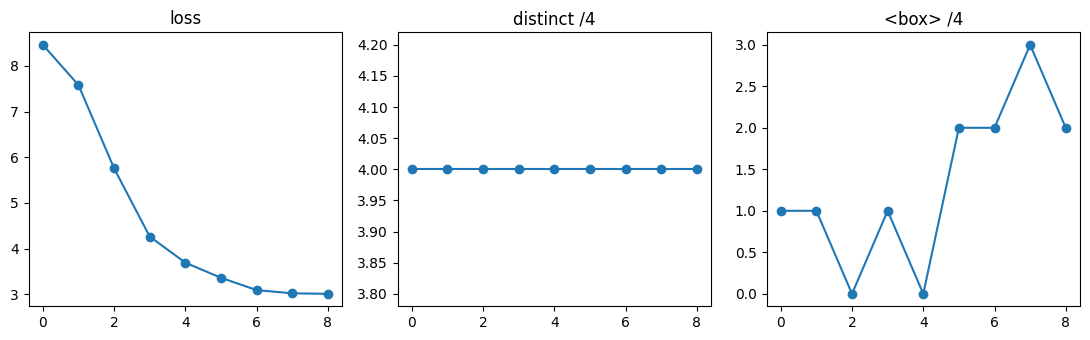

In [ ]:
import pandas as pd
df = pd.DataFrame(log)
print(df.to_string(index=False))

cand = df[df.n_box > 0]
if len(cand):
    best = cand.sort_values(["n_box", "distinct"], ascending=False).iloc[0]
    print(f"\nbest: step {best['step']} | <box> {best['n_box']}/4 | "
          f"distinct {best['distinct']}/4 | loss {best['loss']:.4f}")
else:
    best = df.sort_values("distinct", ascending=False).iloc[0]
    print(f"\nNO checkpoint emitted boxes. Best by diversity: step {best['step']}")

plt.figure(figsize=(11, 3.5))
plt.subplot(1, 3, 1); plt.plot(range(len(df)), df.loss, "o-"); plt.title("loss")
plt.subplot(1, 3, 2); plt.plot(range(len(df)), df.distinct, "o-"); plt.title("distinct /4")
plt.subplot(1, 3, 3); plt.plot(range(len(df)), df.n_box, "o-"); plt.title("<box> /4")
plt.tight_layout(); plt.show()

### 11.1 Load the selected checkpoint

In [ ]:
from peft import set_peft_model_state_dict
SEL = str(best["step"])
p = f"{OUT_ROOT}/run_{RUN_NAME}/" + ("final.pt" if SEL == "final" else f"step{SEL}.pt")
st = torch.load(p, map_location=device)
adapter.load_state_dict(st["adapter"])
set_peft_model_state_dict(llm, st["lora"])
with torch.no_grad():
    w = llm.get_input_embeddings().weight
    w[-68:] = st["coord"].to(w.dtype).to(w.device)
llm.eval(); adapter.eval()
print(f"loaded {p} | distinct {st['distinct']}/4 | <box> {st['n_box']}/4")

loaded /content/drive/MyDrive/MSC_VLM_GROUNDED/run_B_final/step2400.pt | distinct 4/4 | <box> 3/4


## 12. Inference

Forced format + sampled decoding. Greedy under-produces boxes because `</obj>`
is the majority continuation in training.

In [ ]:
def generate_grounded(study, temperature=0.7, top_p=0.9, n=1):
    outs = []
    for _ in range(n):
        raw = peek_forced(study, sampled=True)
        outs.append(parse_generation(raw))
    return outs[0] if n == 1 else outs


for st_ in te_abn[:5]:
    print("=" * 74)
    print("REFERENCE")
    for s, b in zip(st_["sentences"], st_["boxes"]):
        print(f"  [{len(b)} box] {s[:64]}")
    print("GENERATED")
    for s, b in generate_grounded(st_):
        bs = "  ".join("(" + ",".join(f"{v:.2f}" for v in x) + ")" for x in b)
        print(f"  [{len(b)} box] {s[:64]}")
        if b: print(f"           {bs}")

REFERENCE
  [2 box] Prominent hila of probable vascular origin.
  [1 box] Anterior lobulation of the right hemidiaphragm.
  [0 box] No other relevant findings.
GENERATED


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1128: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(


  [0 box] The left lower lobe shows no abnormalities.
REFERENCE
  [1 box] Signs of air trapping.
GENERATED
  [0 box] Right heart chamber dilation.
  [0 box] Cardiomegaly.</box>Right atrial enlargement.
REFERENCE
  [1 box] Alveolar infiltrate in the lingula.
  [1 box] Volume loss in the lingula.
GENERATED
  [0 box] Left hilar mass, right lower lobe at
REFERENCE
  [1 box] Dorsolumbar scoliosis.
GENERATED
  [0 box] Atelectasis.<box>
REFERENCE
  [1 box] Abscess.
  [1 box] Cavitary mass in the left upper lobe.
  [1 box] Nodule projected in the lower right field.
  [1 box] Probable nipple.
GENERATED
  [0 box] <obj>Left hilar region is mildly enlarged.<|im_end|>


### 12.1 Visualise predicted boxes

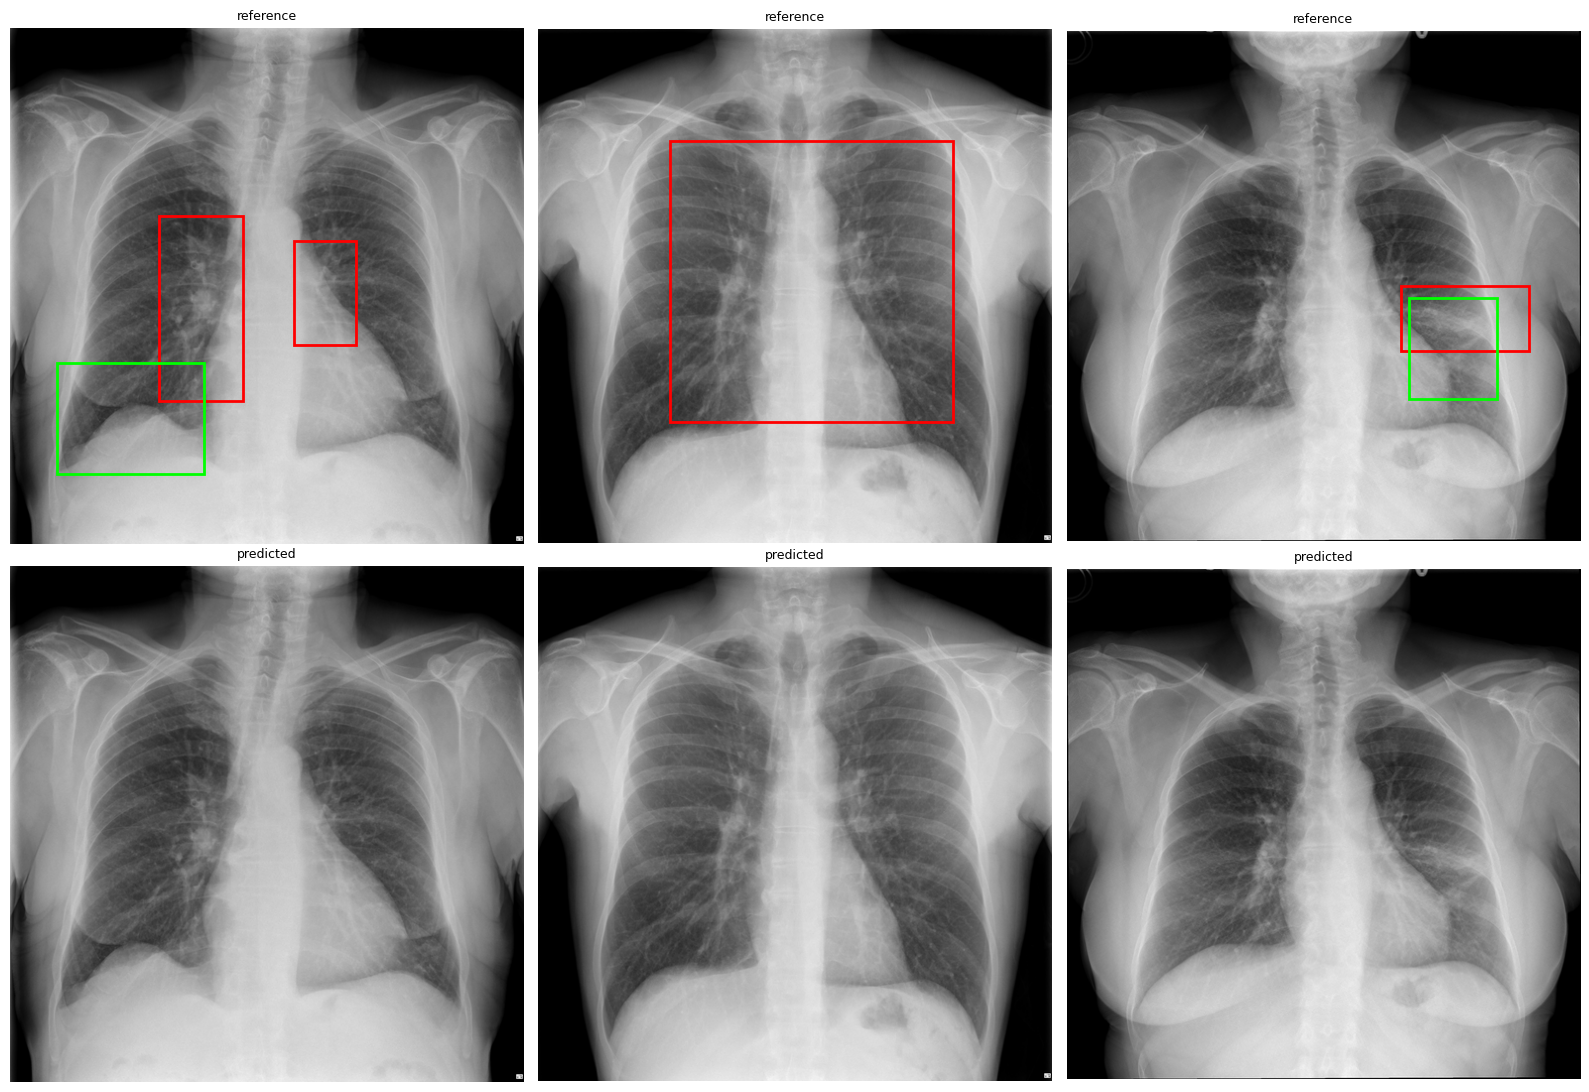

In [ ]:
import matplotlib.patches as mpatches
COLS = ["red", "lime", "cyan", "yellow"]

show = [s for s in te_abn if any(s["boxes"])][:3]
fig, ax = plt.subplots(2, 3, figsize=(16, 11))
for k, st_ in enumerate(show):
    img = Image.open(st_["path"]); Wd, Ht = img.size
    ax[0, k].imshow(img); ax[0, k].set_title("reference", fontsize=9)
    for si, bl in enumerate(st_["boxes"]):
        for b in bl:
            ax[0, k].add_patch(mpatches.Rectangle((b[0], b[1]), b[2]-b[0],
                                                  b[3]-b[1], fill=False,
                                                  ec=COLS[si % 4], lw=2))
    ax[1, k].imshow(img); ax[1, k].set_title("predicted", fontsize=9)
    for si, (s, bl) in enumerate(generate_grounded(st_)):
        for b in bl:
            ax[1, k].add_patch(mpatches.Rectangle((b[0]*Wd, b[1]*Ht),
                                                  (b[2]-b[0])*Wd, (b[3]-b[1])*Ht,
                                                  fill=False, ec=COLS[si % 4],
                                                  lw=2, ls="--"))
    for r in (0, 1): ax[r, k].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
s = te_abn[0]
px, _, _ = preprocess(Image.open(s["path"]))
vis = adapter(encode_image(vision, px[None]).float())
prompt = SYSTEM + INSTR_GROUNDREP + "<obj>Consolidation in the right lower lobe."
ids = tok(prompt, return_tensors="pt")["input_ids"].to(device)
emb = llm.get_input_embeddings()(ids)
inp = torch.cat([vis.to(emb.dtype), emb], dim=1)
with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.float16):
    logits = llm(inputs_embeds=inp,
                 attention_mask=torch.ones(inp.shape[:2], dtype=torch.long,
                                           device=device)).logits
p = torch.softmax(logits[0, -1].float(), -1)
print("next token after a complete finding:")
for v, i in zip(*[t.tolist() for t in p.topk(6)]):
    print(f"  {tok.convert_ids_to_tokens([i])[0]:12s} {v:.4f}")
print(f"\nP(<box>)  = {p[tok.convert_tokens_to_ids('<box>')].item():.4f}")
print(f"P(</obj>) = {p[tok.convert_tokens_to_ids('</obj>')].item():.4f}")
print("\n  P(<box>) high but boxes absent under sampling -> decoding problem:")
print("  prefill a finding sentence and let the model complete the box.")

next token after a complete finding:
  <box>        0.2321
  </obj>       0.2215
  <|im_end|>   0.1924
  </box>       0.0539
  <obj>        0.0518
  Ġ[           0.0125

P(<box>)  = 0.2321
P(</obj>) = 0.2215

  P(<box>) high but boxes absent under sampling -> decoding problem:
  prefill a finding sentence and let the model complete the box.


In [ ]:
for T in [0.3, 0.5, 0.7]:
    print(f"\n--- T={T} ---")
    for s in te_abn[:3]:
        px, _, _ = preprocess(Image.open(s["path"]))
        vis = adapter(encode_image(vision, px[None]).float())
        ids = tok(SYSTEM + INSTR_GROUNDREP + "<obj>", return_tensors="pt")["input_ids"].to(device)
        e = llm.get_input_embeddings()(ids)
        inp = torch.cat([vis.to(e.dtype), e], dim=1)
        with torch.no_grad():
            o = llm.generate(inputs_embeds=inp,
                             attention_mask=torch.ones(inp.shape[:2], dtype=torch.long, device=device),
                             max_new_tokens=120, do_sample=True, top_p=0.9,
                             temperature=T, pad_token_id=tok.eos_token_id)
        print("  <obj>" + tok.decode(o[0], skip_special_tokens=False)[:100])


--- T=0.3 ---
  <obj>Pleural effusion.<box><box><box><box><box><box><box><box><box><box><box><box><box><box><box><box><bo
  <obj>Atelectasis in the left lower lobe.</obj><obj></obj><obj></obj><obj></obj><obj></obj><obj></obj><obj
  <obj> Bilateral pulmonary hyperinflation.<box></obj></box></obj><obj></obj></box></obj><obj></obj></box><

--- T=0.5 ---
  <obj>Atelectasis in the right lower lobe.</obj></box></obj><obj></obj><obj></obj><obj></obj><obj></obj></
  <obj>The right hilar region is enlarged.</obj><obj>The left hilum is not visualized.</obj><obj>No other s
  <obj> Bilateral hyperlucency of the lungs.<box></obj><y19></box></obj><x13></box></obj><y28></box></obj><

--- T=0.7 ---
  <obj>Atria, right, is enlarged.<|im_end|>
  <obj>Atelectasis in the right middle lobe.</obj><obj></obj><obj></obj><obj></obj></box></obj><obj></obj><
  <obj> Aortic aneurysm.<box></obj></box></obj><obj></obj></box></obj></box></obj></box></obj></box></obj><


In [ ]:
import re
raw_box = 0; parsed_box = 0; n = 0
for s in te_abn[:20]:
    raw = peek_forced(s, sampled=True)
    n += 1
    raw_box += raw.count("<box>")
    parsed_box += sum(len(b) for _, b in parse_generation(raw))
print(f"{n} studies | <box> tags emitted: {raw_box} | boxes parsed: {parsed_box}")
print(f"parse failure rate: {100*(1-parsed_box/max(1,raw_box)):.0f}%")

# what do the malformed ones look like?
for s in te_abn[:3]:
    raw = peek_forced(s, sampled=True)
    print("\nRAW   :", raw[:130])
    print("PARSED:", parse_generation(raw))

20 studies | <box> tags emitted: 12 | boxes parsed: 0
parse failure rate: 100%

RAW   : <obj>Pleural effusion, on the right side.<box><y18><x22><y24><y9>2<x26><|im_end|>
PARSED: [('<obj>Pleural effusion, on the right side.<box><y18><x22><y24><y9>2<x26><|im_end|>', [])]

RAW   : <obj>Right upper lung field hyperinflation, emphysema.<box><x15></box></obj><obj>Atelectasis in the right middle lobe segment <x20
PARSED: [('Right upper lung field hyperinflation, emphysema.', []), ('Atelectasis in the right middle lobe segment <x20>.<box><x15><y10>', [])]

RAW   : <obj>No abnormality.<|im_end|>
PARSED: [('<obj>No abnormality.<|im_end|>', [])]


In [ ]:
import torch

X_IDS = torch.tensor(tok.convert_tokens_to_ids([f"<x{i}>" for i in range(32)]))
Y_IDS = torch.tensor(tok.convert_tokens_to_ids([f"<y{i}>" for i in range(32)]))
BOX_O = tok.convert_tokens_to_ids("<box>");  BOX_C = tok.convert_tokens_to_ids("</box>")
OBJ_O = tok.convert_tokens_to_ids("<obj>");  OBJ_C = tok.convert_tokens_to_ids("</obj>")

@torch.no_grad()
def generate_constrained(study, max_new=160, temperature=0.7, top_p=0.9):
    """
    Free generation for text; inside <box> the grammar is FORCED:
    exactly <x><y><x><y> then </box>. The model chooses WHICH coordinates,
    the constraint only fixes the ORDER.
    """
    px, _, _ = preprocess(Image.open(study["path"]))
    vis = adapter(encode_image(vision, px[None]).float())
    ids = tok(SYSTEM + INSTR_GROUNDREP + "<obj>", return_tensors="pt")["input_ids"].to(device)
    emb = llm.get_input_embeddings()(ids)
    inp = torch.cat([vis.to(emb.dtype), emb], dim=1)

    out_ids, in_box = [], -1          # -1 outside a box; 0..3 = coordinate slot
    for _ in range(max_new):
        with torch.amp.autocast("cuda", dtype=torch.float16):
            logits = llm(inputs_embeds=inp,
                         attention_mask=torch.ones(inp.shape[:2], dtype=torch.long,
                                                   device=device)).logits[0, -1].float()
        if in_box >= 0:                                   # inside a box
            allowed = (X_IDS if in_box % 2 == 0 else Y_IDS).to(device)
            mask = torch.full_like(logits, float("-inf"))
            mask[allowed] = logits[allowed]
            logits = mask
        else:
            logits[BOX_C] = float("-inf")

        p = torch.softmax(logits / temperature, -1)
        sp, si = p.sort(descending=True)
        keep = (sp.cumsum(-1) - sp) < top_p
        sp, si = sp[keep], si[keep]
        nxt = si[torch.multinomial(sp / sp.sum(), 1)].item()

        if in_box >= 0:
            in_box += 1
            if in_box == 4:
                out_ids.append(nxt); nxt = BOX_C; in_box = -1
        elif nxt == BOX_O:
            in_box = 0

        out_ids.append(nxt)
        if nxt == tok.eos_token_id: break
        e = llm.get_input_embeddings()(torch.tensor([[nxt]], device=device))
        inp = torch.cat([inp, e.to(inp.dtype)], dim=1)

    return "<obj>" + tok.decode(out_ids, skip_special_tokens=False)


for s in te_abn[:5]:
    raw = generate_constrained(s)
    print("RAW   :", raw[:120])
    print("PARSED:", [(t[:45], len(b)) for t, b in parse_generation(raw)], "\n")

RAW   : <obj>Acute atelectasis in left lower lobe.<box><x18><y22><x20><y21></box></obj><y7><y26><obj></obj><obj></obj><obj></obj
PARSED: [('Acute atelectasis in left lower lobe.', 1)] 

RAW   : <obj>Atriums, ventricles, and atrioventricular canals are not enlarged.<box><x17><y13><x12><y4></box><box><x6><y6><x12><
PARSED: [('Atriums, ventricles, and atrioventricular can', 2), ('<y21><obj>', 0)] 

RAW   : <obj>**<obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><obj><ob
PARSED: [('<obj>**<obj><obj><obj><obj><obj><obj><obj><ob', 0)] 

RAW   : <obj>No significant findings.<|im_end|>
PARSED: [('<obj>No significant findings.<|im_end|>', 0)] 

RAW   : <obj>Left atrial enlargement.<|im_end|>
PARSED: [('<obj>Left atrial enlargement.<|im_end|>', 0)] 



In [ ]:
import torch, numpy as np

X_IDS = torch.tensor(tok.convert_tokens_to_ids([f"<x{i}>" for i in range(32)]))
Y_IDS = torch.tensor(tok.convert_tokens_to_ids([f"<y{i}>" for i in range(32)]))
BOX_O = tok.convert_tokens_to_ids("<box>");  BOX_C = tok.convert_tokens_to_ids("</box>")
OBJ_O = tok.convert_tokens_to_ids("<obj>");  OBJ_C = tok.convert_tokens_to_ids("</obj>")


@torch.no_grad()
def generate_constrained(study, max_new=200, temperature=0.7, top_p=0.9,
                         max_obj=4):

    px, _, _ = preprocess(Image.open(study["path"]))
    vis = adapter(encode_image(vision, px[None]).float())
    ids = tok(SYSTEM + INSTR_GROUNDREP + "<obj>", return_tensors="pt")["input_ids"].to(device)
    emb = llm.get_input_embeddings()(ids)
    inp = torch.cat([vis.to(emb.dtype), emb], dim=1)

    out_ids, in_box, n_obj = [], -1, 1
    for _ in range(max_new):
        with torch.amp.autocast("cuda", dtype=torch.float16):
            logits = llm(inputs_embeds=inp,
                         attention_mask=torch.ones(inp.shape[:2], dtype=torch.long,
                                                   device=device)).logits[0, -1].float()
        if in_box >= 0:
            allowed = (X_IDS if in_box % 2 == 0 else Y_IDS).to(device)
            m = torch.full_like(logits, float("-inf")); m[allowed] = logits[allowed]
            logits = m


        else:
            logits[BOX_C] = float("-inf")

            logits[X_IDS.to(device)] = float("-inf")
            logits[Y_IDS.to(device)] = float("-inf")
            if out_ids and out_ids[-1] == OBJ_C:
                logits[OBJ_O] -= 3.0





        p = torch.softmax(logits / temperature, -1)
        sp, si = p.sort(descending=True)
        keep = (sp.cumsum(-1) - sp) < top_p
        sp, si = sp[keep], si[keep]
        nxt = si[torch.multinomial(sp / sp.sum(), 1)].item()

        if in_box >= 0:
            in_box += 1
            if in_box == 4:
                out_ids.append(nxt); nxt = BOX_C; in_box = -1
        elif nxt == BOX_O:
            in_box = 0
        elif nxt == OBJ_C:
            n_obj += 1
            out_ids.append(nxt)
            break


        out_ids.append(nxt)
        if nxt == tok.eos_token_id or n_obj > max_obj:
            break
        e = llm.get_input_embeddings()(torch.tensor([[nxt]], device=device))
        inp = torch.cat([inp, e.to(inp.dtype)], dim=1)

    txt = tok.decode(out_ids, skip_special_tokens=False)
    txt = txt.split("<|im_end|>")[0]
    return "<obj>" + txt

In [ ]:
for s in te_abn[:5]:
    raw = generate_constrained(s)
    print("RAW   :", raw[:130])
    print("PARSED:", [(t[:45], len(b)) for t, b in parse_generation(raw)], "\n")

RAW   : <obj>The right lower lung field is increased in size.
PARSED: [('<obj>The right lower lung field is increased ', 0)] 

RAW   : <obj>Cardiomegaly.</obj>
PARSED: [('Cardiomegaly.', 0)] 

RAW   : <obj>Fibrous plaques are seen in the left pulmonary hilum.<box><x5><y16><x24><y16></box></obj>
PARSED: [('Fibrous plaques are seen in the left pulmonar', 1)] 

RAW   : <obj>Subcutaneous fluid on the right side.
PARSED: [('<obj>Subcutaneous fluid on the right side.', 0)] 

RAW   : <obj>Retrosternal aortic aortic arch.
PARSED: [('<obj>Retrosternal aortic aortic arch.', 0)] 



In [ ]:
bad = tot = 0
for s in te_abn[:20]:
    for _, bl in parse_generation(generate_constrained(s, max_new=200)):
        for b in bl:
            tot += 1
            if b[2] <= b[0] or b[3] <= b[1]: bad += 1
print(f"{bad}/{tot} boxes have inverted coordinates ({100*bad/max(1,tot):.0f}%)")

2/3 boxes have inverted coordinates (67%)


In [ ]:
import numpy as np
from PIL import Image


def normalise_box(b):

    return (min(b[0], b[2]), min(b[1], b[3]), max(b[0], b[2]), max(b[1], b[3]))


def iou(a, b):
    x0, y0 = max(a[0], b[0]), max(a[1], b[1])
    x1, y1 = min(a[2], b[2]), min(a[3], b[3])
    i = max(0, x1 - x0) * max(0, y1 - y0)
    u = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - i
    return i / u if u > 0 else 0.0


N_EVAL = 25
ious, ious_raw = [], []
n_pred = n_with = n_inv = 0
areas = []

for k, s in enumerate(te_abn[:N_EVAL]):
    raw = generate_constrained(s, max_new=200)
    pred = [b for _, bl in parse_generation(raw) for b in bl]
    gt = [b for bl in s["boxes"] for b in bl]
    if pred: n_with += 1
    n_pred += len(pred)
    if not pred or not gt:
        continue
    W, H = Image.open(s["path"]).size
    for p in pred:
        if p[2] <= p[0] or p[3] <= p[1]:
            n_inv += 1
        pn = normalise_box(p)
        px_box = [pn[0]*W, pn[1]*H, pn[2]*W, pn[3]*H]
        ious.append(max(iou(px_box, g) for g in gt))
        ious_raw.append(max(iou([p[0]*W, p[1]*H, p[2]*W, p[3]*H], g) for g in gt))
        areas.append((pn[2]-pn[0]) * (pn[3]-pn[1]))
    if (k + 1) % 5 == 0:
        print(f"  {k+1}/{N_EVAL} | {n_with} with boxes | {len(ious)} scored")

print(f"\n{n_with}/{N_EVAL} studies produced boxes | {n_pred} boxes | "
      f"{n_inv} inverted ({100*n_inv/max(1,n_pred):.0f}%)")
if ious:
    print(f"mean IoU (normalised) {np.mean(ious):.4f}")
    print(f"mean IoU (raw)        {np.mean(ious_raw):.4f}")
    print(f"IoU>0.1  {100*np.mean([i>0.1 for i in ious]):.1f}%")
    print(f"IoU>0.25 {100*np.mean([i>0.25 for i in ious]):.1f}%")
    print(f"mean predicted box area (normalised units) {np.mean(areas):.3f}")
else:
    print("no boxes scored")

  15/25 | 9 with boxes | 13 scored
  25/25 | 12 with boxes | 16 scored

12/25 studies produced boxes | 16 boxes | 10 inverted (62%)
mean IoU (normalised) 0.0685
mean IoU (raw)        0.0376
IoU>0.1  31.2%
IoU>0.25 0.0%
mean predicted box area (normalised units) 0.056


# Archive

In [ ]:
import shutil, os
src = f"{OUT_ROOT}/run_B_final"
dst = f"{OUT_ROOT}/run_B_final_ep1_IoU069"
if not os.path.exists(dst):
    shutil.copytree(src, dst)
print("archived:", dst)

json.dump({"epochs": 1, "n_studies": 25, "with_boxes": 12, "n_boxes": 16,
           "inverted_pct": 62, "mean_iou_norm": 0.0685, "mean_iou_raw": 0.0376,
           "iou_gt_0.1": 31.2, "iou_gt_0.25": 0.0, "mean_box_area": 0.056},
          open(f"{dst}/grounding_eval.json", "w"), indent=2)

archived: /content/drive/MyDrive/MSC_VLM_GROUNDED/run_B_final_ep1_IoU069


In [ ]:
from peft import set_peft_model_state_dict, get_peft_model_state_dict
from transformers import get_cosine_schedule_with_warmup
import torch, numpy as np, json, os, time


def box_stats(outs):

    tot = inv = 0
    for o in outs:
        for _, bl in parse_generation(o):
            for b in bl:
                tot += 1
                if b[2] <= b[0] or b[3] <= b[1]:
                    inv += 1
    return tot, inv


def p_box(study):

    px, _, _ = preprocess(Image.open(study["path"]))
    vis = adapter(encode_image(vision, px[None]).float())
    ids = tok(SYSTEM + INSTR_GROUNDREP + "<obj>Consolidation in the right lower lobe.",
              return_tensors="pt")["input_ids"].to(device)
    e = llm.get_input_embeddings()(ids)
    inp = torch.cat([vis.to(e.dtype), e], dim=1)
    with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.float16):
        lg = llm(inputs_embeds=inp,
                 attention_mask=torch.ones(inp.shape[:2], dtype=torch.long,
                                           device=device)).logits[0, -1].float()
    p = torch.softmax(lg, -1)
    return (p[tok.convert_tokens_to_ids("<box>")].item(),
            p[tok.convert_tokens_to_ids("</obj>")].item())


def train_final2(run_name, train_ds, val_ds, epochs=2, ckpt_every=300):
    out_dir = os.path.join(OUT_ROOT, f"run_{run_name}")
    os.makedirs(out_dir, exist_ok=True)
    collate = make_collate(tok)
    tl = DataLoader(train_ds, batch_size=CFG.BATCH, shuffle=True,
                    collate_fn=collate, num_workers=2)
    vl = DataLoader(val_ds, batch_size=CFG.BATCH, shuffle=False, collate_fn=collate)

    groups = [
        {"params": list(adapter.parameters()), "lr": CFG.LR_ADAPTER},
        {"params": [p for n, p in llm.named_parameters()
                    if p.requires_grad and "embed_tokens" not in n], "lr": CFG.LR},
        {"params": [p for n, p in llm.named_parameters()
                    if p.requires_grad and "embed_tokens" in n], "lr": CFG.LR_ADAPTER},
    ]
    groups = [g for g in groups if g["params"]]
    opt = torch.optim.AdamW(groups, weight_decay=0.01)
    steps = max(1, (len(tl) // CFG.ACCUM) * epochs)
    sch = get_cosine_schedule_with_warmup(opt, int(steps * CFG.WARMUP_FRAC), steps)
    scaler = torch.amp.GradScaler()
    log, t0 = [], time.time()

    print("BASELINE (resumed from epoch 1)")
    outs = [peek_forced(s) for s in check_pool]
    tot, inv = box_stats(outs)
    pb, po = p_box(check_pool[0])
    print(f"  <box> {sum(1 for o in outs if '<box>' in o)}/4 | boxes {tot} | "
          f"inverted {inv}/{max(1,tot)} | P(<box>) {pb:.3f} vs P(</obj>) {po:.3f}\n")

    for ep in range(1, epochs + 1):
        llm.train(); adapter.train()
        running = []
        for i, b in enumerate(tl):
            with torch.amp.autocast("cuda", dtype=torch.float16):
                loss = forward_loss(vision, llm, adapter, b)
            scaler.scale(loss / CFG.ACCUM).backward()
            if (i + 1) % CFG.ACCUM == 0:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(
                    [p for g in groups for p in g["params"]], 1.0)
                prev = scaler.get_scale()
                scaler.step(opt); scaler.update(); opt.zero_grad()
                if scaler.get_scale() >= prev:
                    sch.step()
            running.append(loss.item())

            if i > 0 and i % ckpt_every == 0:
                llm.eval(); adapter.eval()
                ml = float(np.mean(running[-ckpt_every:]))
                outs = [peek_forced(s) for s in check_pool]
                nd = len(set(outs))
                nb = sum(1 for o in outs if "<box>" in o)
                tot, inv = box_stats(outs)
                pb, po = p_box(check_pool[0])
                sr = signal_ratio(adapter, check_pool)
                print(f"  ep{ep} [{i}/{len(tl)}] loss {ml:.4f} | {(time.time()-t0)/60:.0f}m")
                print(f"    distinct {nd}/4 | <box> {nb}/4 | boxes {tot} | "
                      f"inverted {inv}/{max(1,tot)} ({100*inv/max(1,tot):.0f}%)")
                print(f"    P(<box>) {pb:.3f} vs P(</obj>) {po:.3f} | "
                      f"signal {sr:.3f} | scale {adapter.scale.item():.5f}")
                print(f"    {outs[0][:95]}")
                torch.save({"epoch": ep, "step": i, "loss": ml, "distinct": nd,
                            "n_box": nb, "boxes": tot, "inverted": inv,
                            "p_box": pb, "p_obj": po,
                            "adapter": adapter.state_dict(),
                            "lora": get_peft_model_state_dict(llm),
                            "coord": llm.get_input_embeddings().weight[-68:].detach().cpu()},
                           f"{out_dir}/ep{ep}_step{i}.pt")
                log.append({"epoch": ep, "step": i, "loss": ml, "distinct": nd,
                            "n_box": nb, "boxes": tot, "inverted": inv,
                            "inv_pct": 100*inv/max(1, tot), "p_box": pb,
                            "signal": sr})
                json.dump(log, open(f"{out_dir}/steplog.json", "w"), indent=2)
                llm.train(); adapter.train()

        llm.eval(); adapter.eval()
        with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.float16):
            vloss = float(np.mean([forward_loss(vision, llm, adapter, b).item()
                                   for b in vl]))
        outs = [peek_forced(s) for s in check_pool]
        tot, inv = box_stats(outs)
        pb, po = p_box(check_pool[0])
        print(f"\nEPOCH {ep} val {vloss:.4f} | <box> "
              f"{sum(1 for o in outs if '<box>' in o)}/4 | "
              f"inverted {inv}/{max(1,tot)} | P(<box>) {pb:.3f}")
        torch.save({"epoch": ep, "step": "final", "loss": vloss,
                    "distinct": len(set(outs)),
                    "n_box": sum(1 for o in outs if "<box>" in o),
                    "boxes": tot, "inverted": inv, "p_box": pb, "p_obj": po,
                    "adapter": adapter.state_dict(),
                    "lora": get_peft_model_state_dict(llm),
                    "coord": llm.get_input_embeddings().weight[-68:].detach().cpu()},
                   f"{out_dir}/ep{ep}_final.pt")
        tok.save_pretrained(f"{out_dir}/tokenizer")
        log.append({"epoch": ep, "step": "final", "loss": vloss,
                    "n_box": sum(1 for o in outs if "<box>" in o),
                    "boxes": tot, "inverted": inv,
                    "inv_pct": 100*inv/max(1, tot), "p_box": pb,
                    "signal": signal_ratio(adapter, check_pool)})
        json.dump(log, open(f"{out_dir}/steplog.json", "w"), indent=2)

    print(f"\ndone in {(time.time()-t0)/60:.0f} min | {out_dir}")
    return log


# resume from epoch 1
st = torch.load(f"{OUT_ROOT}/run_B_final/final.pt", map_location=device)
adapter.load_state_dict(st["adapter"])
set_peft_model_state_dict(llm, st["lora"])
with torch.no_grad():
    w = llm.get_input_embeddings().weight
    w[-68:] = st["coord"].to(w.dtype).to(w.device)
print(f"resumed | epoch-1 <box> {st['n_box']}/4, distinct {st['distinct']}/4")

log2 = train_final2("B_final_ep23", PadChestGRDataset(tr_abn, 1.0),
                    PadChestGRDataset(va_abn, 1.0), epochs=2, ckpt_every=300)

resumed | epoch-1 <box> 2/4, distinct 4/4
  2479 grounded / 0 ungrounded (100.0%)
  310 grounded / 0 ungrounded (100.0%)
BASELINE (resumed from epoch 1)
  <box> 4/4 | boxes 0 | inverted 0/1 | P(<box>) 0.222 vs P(</obj>) 0.330

  ep1 [300/2479] loss 2.9631 | 9m
    distinct 4/4 | <box> 4/4 | boxes 0 | inverted 0/1 (0%)
    P(<box>) 0.221 vs P(</obj>) 0.527 | signal 0.357 | scale 0.02185
    <obj>Atelectasis in the right middle lobe.</obj><obj>Lung hyperinflation.<box><x12></box>No oth


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:386: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


  ep1 [600/2479] loss 2.7492 | 17m
    distinct 4/4 | <box> 3/4 | boxes 0 | inverted 0/1 (0%)
    P(<box>) 0.448 vs P(</obj>) 0.492 | signal 0.352 | scale 0.02206
    <obj>A <x16>.<x19> cm pulmonary nodule in the right lower lobe.</obj><obj></obj><obj></obj><obj
  ep1 [900/2479] loss 2.5386 | 25m
    distinct 4/4 | <box> 3/4 | boxes 1 | inverted 1/1 (100%)
    P(<box>) 0.539 vs P(</obj>) 0.407 | signal 0.350 | scale 0.02192
    <obj>Pneumothorax on the left.<box><x11><y12></box></obj><obj>Atelectasis in the right lower lo
  ep1 [1200/2479] loss 2.4260 | 33m
    distinct 4/4 | <box> 4/4 | boxes 0 | inverted 0/1 (0%)
    P(<box>) 0.855 vs P(</obj>) 0.116 | signal 0.350 | scale 0.02168
    <obj>Lobar consolidation in the right lower lobe.<box><x21><y8></box></obj><|im_end|>
  ep1 [1500/2479] loss 2.3828 | 41m
    distinct 4/4 | <box> 2/4 | boxes 1 | inverted 0/1 (0%)
    P(<box>) 0.819 vs P(</obj>) 0.154 | signal 0.349 | scale 0.02167
    <obj>Scoliosis.<box><x4><y15><x14><y23><y17></box>